# Renewable Energy Intelligence

## Data Understanding

### Load Dataset

In [1]:
import pandas as pd

df = pd.read_csv("../data/raw/Renewable.csv")

df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


### Dataset Shape

In [2]:
df.shape

(196776, 17)

### Data Types and Missing Values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  str    
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type            196776 

### Target Variable Summary

In [4]:
df["Energy delta[Wh]"].describe()

count    196776.000000
mean        573.008228
std        1044.824047
min           0.000000
25%           0.000000
50%           0.000000
75%         577.000000
max        5020.000000
Name: Energy delta[Wh], dtype: float64

### Zero Production Analysis

In [5]:
(df["Energy delta[Wh]"] == 0).sum()

np.int64(100850)

### Relationship Between Sunlight and Zero Production

In [6]:
df[df["Energy delta[Wh]"] == 0]["isSun"].value_counts()

isSun
0    94460
1     6390
Name: count, dtype: int64

**Observation:**
94,460 zero-production observations occur when isSun = 0.

**Interpretation:**
This suggests the dataset behaves consistently with solar generation, as energy production is generally absent when sunlight is unavailable.

## Exploratory Data Analysis


### Average Energy Production by Hour


In [7]:
hourly_avg = df.groupby("hour")["Energy delta[Wh]"].mean()

hourly_avg

hour
0        0.000000
1        0.000000
2        0.288049
3       14.915366
4       67.423780
5      176.065732
6      451.680854
7      987.805366
8     1539.441829
9     1831.990976
10    1959.742317
11    1908.332195
12    1684.832927
13    1344.637073
14     968.013171
15     533.892805
16     196.203049
17      66.341098
18      18.133114
19       0.789898
20       0.000000
21       0.000000
22       0.000000
23       0.000000
Name: Energy delta[Wh], dtype: float64

**Observation:**

Average energy production follows a clear daily cycle. Production is near zero during nighttime hours, increases steadily after sunrise, peaks around 10:00, and then gradually decreases toward evening.

**Interpretation:**

This pattern is consistent with solar energy generation and provides additional evidence that the dataset reflects realistic renewable energy production behavior.

### Average Energy Production by Hour Visualization

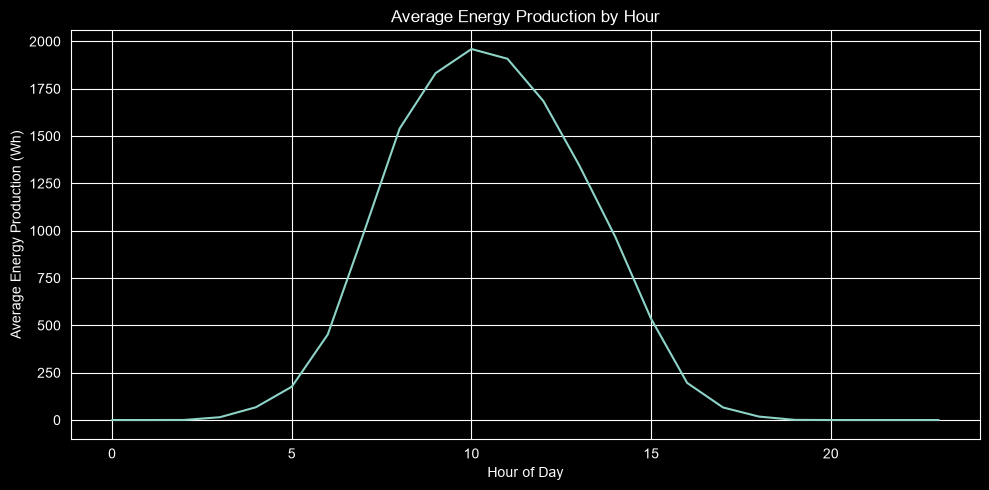

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hourly_avg.plot()
plt.title("Average Energy Production by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/01_average_energy_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Energy production follows a bell-shaped daily pattern, with near-zero production during nighttime hours and peak production around 10:00.

**Interpretation:**

This pattern is characteristic of solar energy systems and indicates that energy generation is strongly influenced by daylight availability.

### Impact of Cloud Cover on Energy Production

In [9]:
cloud_energy = df.groupby("clouds_all")["Energy delta[Wh]"].mean()

cloud_energy.head()

clouds_all
0    913.801816
1    651.694640
2    790.908052
3    769.560219
4    738.896458
Name: Energy delta[Wh], dtype: float64

In [10]:
df["clouds_all"].describe()

count    196776.000000
mean         65.974387
std          36.628593
min           0.000000
25%          34.000000
50%          82.000000
75%         100.000000
max         100.000000
Name: clouds_all, dtype: float64

### Cloud Cover Effects During Sunlight Hours

In [11]:
sun_df = df[df["isSun"] == 1]

sun_df.shape

(102316, 17)

In [12]:
sun_cloud_energy = (
    sun_df.groupby("clouds_all")["Energy delta[Wh]"]
    .mean()
)

sun_cloud_energy.head()

clouds_all
0    1834.884922
1    1461.032411
2    1652.447560
3    1669.072559
4    1525.597750
Name: Energy delta[Wh], dtype: float64

### Average Energy Production by Cloud Cover During Sunlight Hours

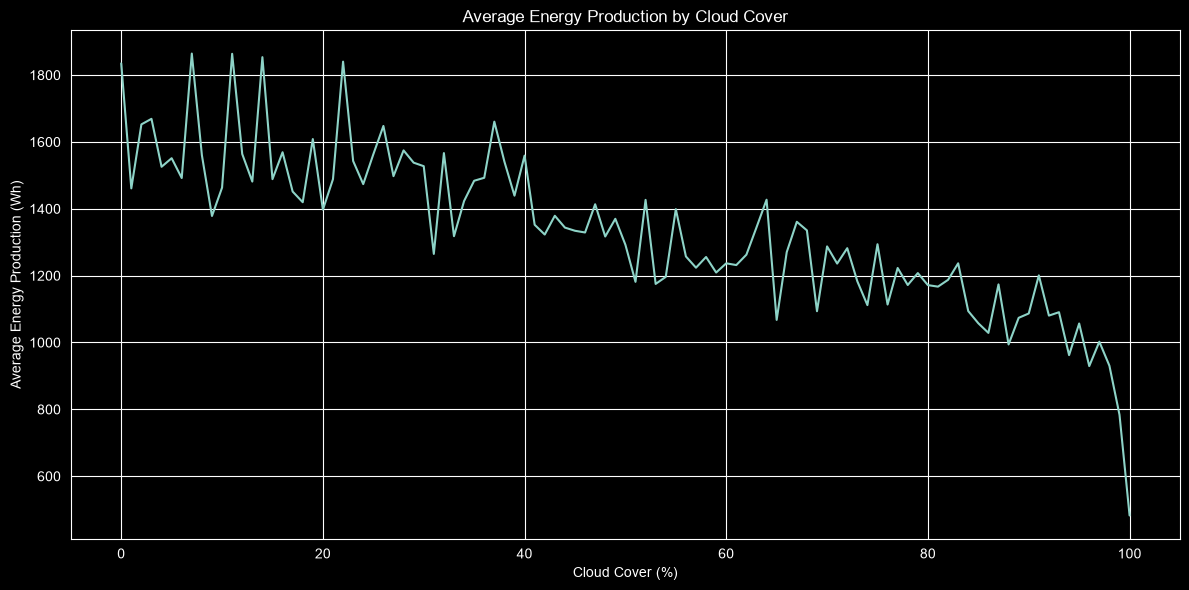

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sun_cloud_energy.plot()

plt.title("Average Energy Production by Cloud Cover")
plt.xlabel("Cloud Cover (%)")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.show()

**Observation:**

Average energy production generally decreases as cloud cover increases. Although the relationship contains fluctuations, the overall trend is negative, indicating that cloudier conditions are associated with lower renewable energy generation.

**Interpretation:**

Cloud cover reduces the amount of solar radiation reaching the system, which lowers energy production. This suggests that cloud cover is likely to be an important predictor in future machine learning models.

### Impact of Global Horizontal Irradiance (GHI) on Energy Production

In [14]:
df["GHI"].describe()

count    196776.000000
mean         32.596538
std          52.172018
min           0.000000
25%           0.000000
50%           1.600000
75%          46.800000
max         229.200000
Name: GHI, dtype: float64

### Relationship Between GHI and Energy Production

In [15]:
ghi_energy = df.groupby("GHI")["Energy delta[Wh]"].mean()

ghi_energy.head()

GHI
0.0    0.010616
0.1    2.284685
0.2    2.231156
0.3    3.312649
0.4    3.670175
Name: Energy delta[Wh], dtype: float64

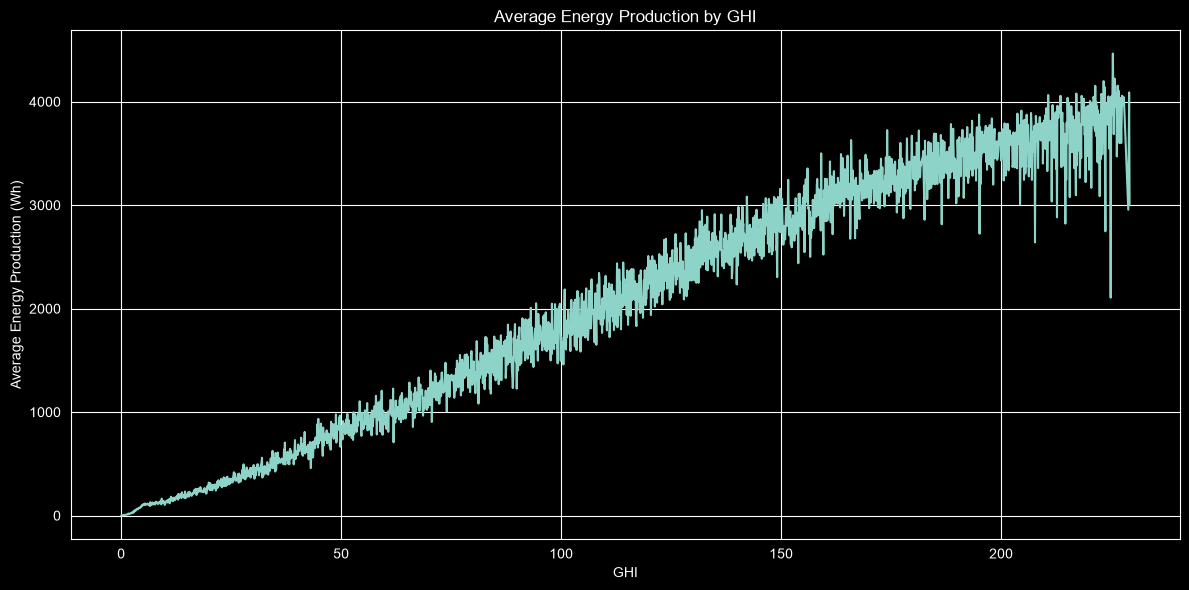

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

ghi_energy.plot()

plt.title("Average Energy Production by GHI")
plt.xlabel("GHI")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/03_ghi_vs_energy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Average energy production increases strongly as GHI increases. The relationship is much clearer than the relationship observed with cloud cover, indicating a strong positive association between solar irradiance and energy generation.

**Interpretation:**

GHI measures the amount of solar energy reaching the surface and is directly related to the physical process of solar power generation. The strong upward trend suggests that GHI will likely be one of the most important predictors in future machine learning models.

### Seasonal Patterns in Energy Production

In [17]:
monthly_avg = df.groupby("month")["Energy delta[Wh]"].mean()

monthly_avg

month
1     129.559145
2     369.194174
3     620.637209
4     851.112211
5     881.579693
6     926.396648
7     811.018425
8     798.917059
9     631.771875
10    397.342668
11    151.741611
12     91.229028
Name: Energy delta[Wh], dtype: float64

**Observation:**

Energy production exhibits a strong seasonal pattern. Average production increases steadily from January to June, peaks in June, and then gradually declines toward December.

**Interpretation:**

This behavior is consistent with solar energy systems, where longer daylight hours and higher solar irradiance during summer months lead to increased energy generation. Seasonal effects appear to be an important factor influencing renewable energy production.

### Average Energy Production by Month Visualization

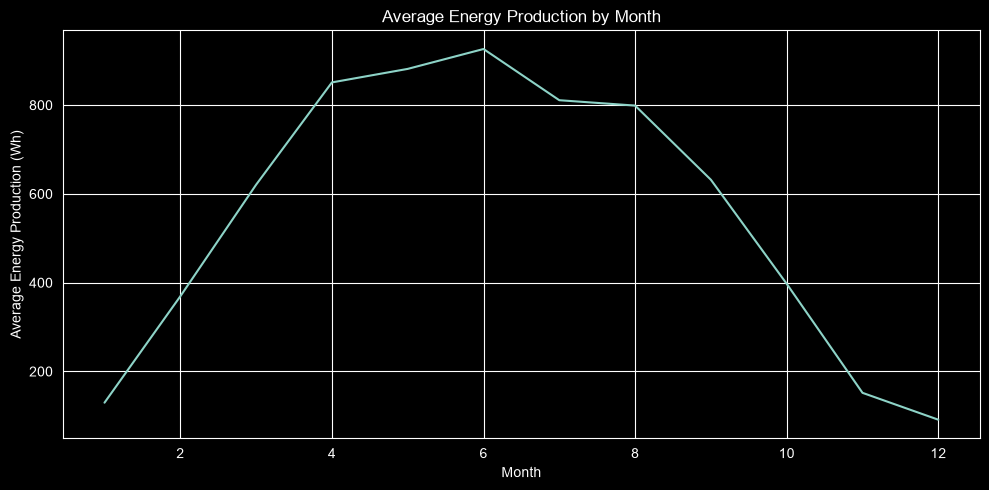

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

monthly_avg.plot()

plt.title("Average Energy Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/04_average_energy_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


**Observation:**

Energy production exhibits a strong seasonal cycle. Average production increases from January to June, reaches its maximum in June, and then gradually decreases toward December.

**Interpretation:**

This pattern is consistent with solar energy systems, where longer daylight hours and higher solar irradiance during summer months increase energy generation. Seasonal effects appear to be one of the most influential factors affecting renewable energy production.

**Key Finding:**

Average energy production in June is approximately ten times higher than in December, highlighting the substantial impact of seasonality on renewable energy generation.

### Correlation Analysis

In [19]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["Energy delta[Wh]"].sort_values(ascending=False)

Energy delta[Wh]          1.000000
GHI                       0.914619
isSun                     0.526952
sunlightTime              0.437296
SunlightTime/daylength    0.402523
temp                      0.378554
dayLength                 0.280695
pressure                  0.115219
wind_speed                0.029385
month                    -0.049307
snow_1h                  -0.050914
rain_1h                  -0.059881
hour                     -0.080877
weather_type             -0.170046
clouds_all               -0.190241
humidity                 -0.544407
Name: Energy delta[Wh], dtype: float64

**Observation:**

GHI exhibits the strongest positive correlation with energy production (0.915), indicating a very strong linear relationship between solar irradiance and energy generation.

Humidity shows the strongest negative correlation (-0.544), while cloud cover also demonstrates a negative relationship with energy production.

Temperature, sunlight availability, and sunlight duration all show meaningful positive relationships with the target variable.

**Interpretation:**

The correlation analysis confirms that solar irradiance is the most influential factor affecting energy production in this dataset. Weather conditions and sunlight-related variables appear to be important predictors and are likely to play a significant role in future machine learning models.

### Impact of Humidity on Energy Production

In [20]:
df["humidity"].describe()

count    196776.000000
mean         79.810566
std          15.604459
min          22.000000
25%          70.000000
50%          84.000000
75%          92.000000
max         100.000000
Name: humidity, dtype: float64

**Observation:**

Humidity levels are generally high throughout the dataset, with a median value of 84% and 75% of observations having humidity levels below 92%.

**Interpretation:**

The dataset is dominated by relatively humid conditions. Since humidity has already shown a strong negative correlation with energy production, it may play an important role in explaining renewable energy generation patterns either directly or through its relationship with cloud cover and solar irradiance.

### Relationship Between Humidity and Energy Production

In [21]:
humidity_energy = (
    df.groupby("humidity")["Energy delta[Wh]"]
    .mean()
)

humidity_energy.head()

humidity
22    2371.187500
23    2515.166667
24    2979.625000
25    1810.321429
26    2284.600000
Name: Energy delta[Wh], dtype: float64

In [22]:
humidity_energy.tail()

humidity
96     79.106192
97     59.815781
98     68.289718
99     64.433121
100    86.455773
Name: Energy delta[Wh], dtype: float64

**Observation:**

Average energy production is substantially higher under low-humidity conditions than under high-humidity conditions. Very dry conditions are associated with some of the highest observed average production values, while extremely humid conditions are associated with very low average production.

**Interpretation:**

This result supports the negative correlation observed earlier and suggests that humidity is strongly associated with renewable energy generation. High humidity may be linked to atmospheric conditions that reduce the amount of solar energy reaching the system.

### Average Energy Production by Humidity

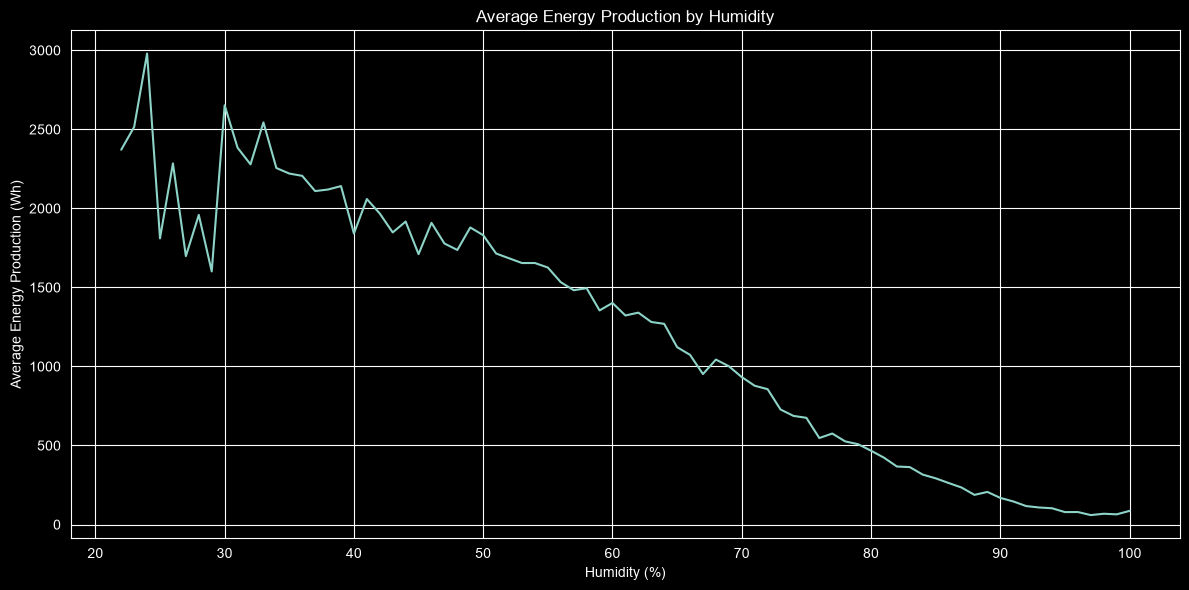

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

humidity_energy.plot()

plt.title("Average Energy Production by Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/05_humidity_vs_energy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Average energy production decreases substantially as humidity increases. The relationship shows a clear negative trend, with low-humidity conditions associated with high energy production and high-humidity conditions associated with very low energy production.

**Interpretation:**

The humidity analysis supports the correlation results and suggests that humidity is an important factor associated with renewable energy generation. High humidity may be linked to atmospheric conditions that reduce solar irradiance and overall energy production.

**Key Finding:**

Humidity exhibits one of the strongest relationships with energy production in the dataset, second only to GHI.

### Correlation Heatmap

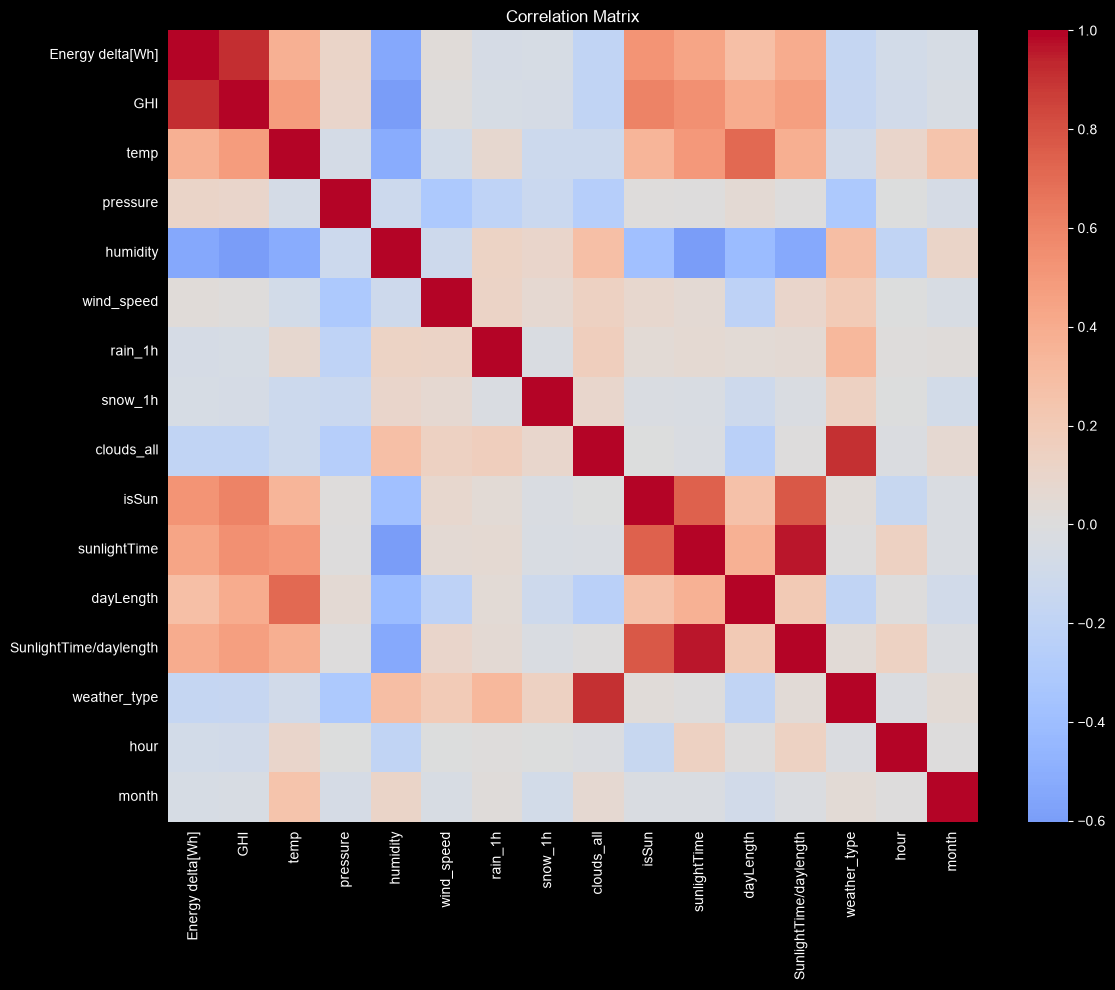

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Observation:**

The correlation heatmap reveals strong relationships among several weather and sunlight-related variables. GHI shows the strongest positive association with energy production, while humidity exhibits a notable negative relationship.

**Interpretation:**

Several sunlight-related variables (isSun, sunlightTime, dayLength, and SunlightTime/daylength) are highly correlated with one another, suggesting they capture similar information. Humidity appears to be associated with lower solar irradiance and reduced energy production, indicating that weather conditions play an important role in renewable energy generation.

**Key Finding:**

The heatmap confirms that solar irradiance (GHI) is the dominant predictor of energy production and highlights important relationships between weather variables and sunlight availability.

### Impact of Temperature on Energy Production

In [25]:
df["temp"].describe()

count    196776.000000
mean          9.790521
std           7.995428
min         -16.600000
25%           3.600000
50%           9.300000
75%          15.700000
max          35.800000
Name: temp, dtype: float64

**Observation:**

Temperature ranges from -16.6°C to 35.8°C, indicating substantial variation across the dataset. Most observations occur under cool to mild conditions, with a median temperature of 9.3°C.

**Interpretation:**

The broad temperature range reflects seasonal variation and may help explain some of the seasonal patterns observed in energy production. Temperature is likely associated with sunlight availability and weather conditions, making it a potentially useful predictor in future machine learning models.

### Relationship Between Temperature and Energy Production

In [26]:
temp_energy = (
    df.groupby("temp")["Energy delta[Wh]"]
    .mean()
)

temp_energy.head()

temp
-16.6       0.000
-16.0      97.500
-15.8    1294.500
-15.7       0.000
-15.6     164.875
Name: Energy delta[Wh], dtype: float64

In [27]:
df["temp"].nunique()

503

### Temperature Binning Analysis

In [28]:
temp_bins = pd.cut(df["temp"], bins=10)

temp_bin_energy = (
    df.groupby(temp_bins)["Energy delta[Wh]"]
    .mean()
)

temp_bin_energy

temp
(-16.652, -11.36]     183.345361
(-11.36, -6.12]       385.794949
(-6.12, -0.88]        227.998078
(-0.88, 4.36]         210.227915
(4.36, 9.6]           353.337900
(9.6, 14.84]          489.880611
(14.84, 20.08]        901.073531
(20.08, 25.32]       1472.856173
(25.32, 30.56]       1923.537990
(30.56, 35.8]        1989.468571
Name: Energy delta[Wh], dtype: float64

**Observation:**

Average energy production generally increases as temperature increases. The warmest temperature ranges are associated with the highest average energy production, while the coldest ranges exhibit substantially lower production.

**Interpretation:**

The relationship suggests that temperature is positively associated with renewable energy generation. However, temperature is likely capturing broader seasonal and sunlight-related effects rather than acting as a direct cause of increased energy production.

**Key Finding:**

The warmest temperature range produces approximately ten times more energy than the coldest temperature range, indicating a strong association between temperature and renewable energy generation.

### Average Energy Production by Temperature Range

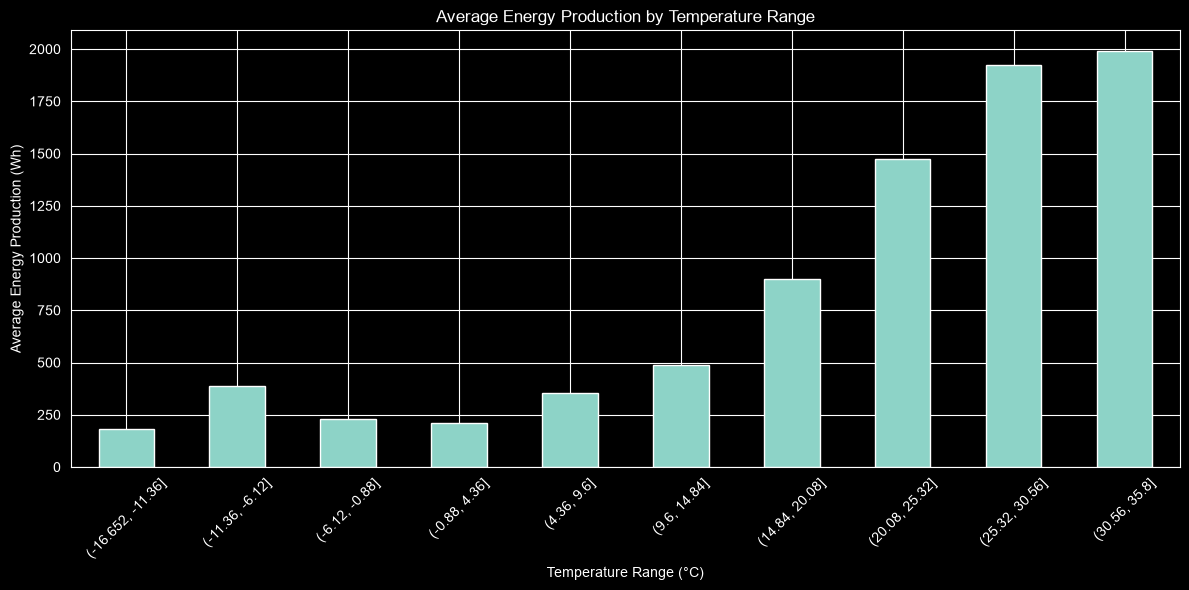

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

temp_bin_energy.plot(kind="bar")

plt.title("Average Energy Production by Temperature Range")
plt.xlabel("Temperature Range (°C)")
plt.ylabel("Average Energy Production (Wh)")

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/07_temperature_vs_energy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Average energy production generally increases across temperature ranges. Production remains relatively low at colder temperatures but rises substantially once temperatures exceed approximately 15°C.

**Interpretation:**

The temperature analysis reveals a strong positive association between temperature and renewable energy generation. This relationship is likely influenced by seasonal factors and solar irradiance rather than temperature alone.

**Key Finding:**

The warmest temperature ranges are associated with the highest average energy production, producing approximately ten times more energy than the coldest temperature ranges.

## Feature Engineering and Data Preparation

### Preparing Features for Machine Learning

In [30]:
df_ml = df.copy()

df_ml["Time"] = pd.to_datetime(df_ml["Time"])

df_ml.info()

<class 'pandas.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   Time                    196776 non-null  datetime64[us]
 1   Energy delta[Wh]        196776 non-null  int64         
 2   GHI                     196776 non-null  float64       
 3   temp                    196776 non-null  float64       
 4   pressure                196776 non-null  int64         
 5   humidity                196776 non-null  int64         
 6   wind_speed              196776 non-null  float64       
 7   rain_1h                 196776 non-null  float64       
 8   snow_1h                 196776 non-null  float64       
 9   clouds_all              196776 non-null  int64         
 10  isSun                   196776 non-null  int64         
 11  sunlightTime            196776 non-null  int64         
 12  dayLength               196776 non-null  

In [31]:
features = df_ml.drop(
    columns=["Time", "Energy delta[Wh]"]
)

features.columns.tolist()

['GHI',
 'temp',
 'pressure',
 'humidity',
 'wind_speed',
 'rain_1h',
 'snow_1h',
 'clouds_all',
 'isSun',
 'sunlightTime',
 'dayLength',
 'SunlightTime/daylength',
 'weather_type',
 'hour',
 'month']

### Creating Features and Target Variables

In [32]:
X = df_ml.drop(
    columns=["Time", "Energy delta[Wh]"]
)

y = df_ml["Energy delta[Wh]"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (196776, 15)
Target shape: (196776,)


**Observation:**

The machine learning dataset contains 196,776 observations and 15 input features. The target variable is Energy delta[Wh], representing renewable energy production.

**Interpretation:**

The dataset is sufficiently large for machine learning applications and includes a diverse set of weather, sunlight, and temporal variables that may contribute to predicting energy generation.

### Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (157420, 15)
X_test : (39356, 15)
y_train: (157420,)
y_test : (39356,)


**Observation:**

The dataset was split into training and testing subsets using an 80/20 ratio. The training set contains 157,420 observations, while the testing set contains 39,356 observations.

**Interpretation:**

Separating training and testing data ensures that model performance can be evaluated on unseen observations. This provides a more realistic assessment of how well the model is likely to perform on new data.

### Baseline Model: Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Observation:**

A Linear Regression model was successfully trained using the training dataset.

**Interpretation:**

Linear Regression serves as a baseline machine learning model. Its performance will provide a reference point against which more advanced models can later be compared.

### Generating Predictions

In [35]:
y_pred = lr_model.predict(X_test)

print(y_pred[:10])

[ 655.18721192  -56.34110694   87.65653135  -81.58775996 1349.95149824
   54.55684748   25.93270471  -16.49359154  -33.11735162  -44.36845078]


### Evaluating the Linear Regression Model

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

MAE : 224.02
RMSE: 396.71
R²  : 0.8572


**Observation:**

The Linear Regression model achieved an R² score of 0.8572, an MAE of 224.02 Wh, and an RMSE of 396.71 Wh on the test dataset.

**Interpretation:**

The model explains approximately 85.7% of the variation in energy production, indicating that the selected features contain substantial predictive information. While prediction errors remain, the results demonstrate that a relatively simple model can capture most of the underlying patterns in the dataset.

**Key Finding:**

Linear Regression provides a strong baseline model for renewable energy prediction and establishes a benchmark for evaluating more advanced machine learning algorithms.

### Random Forest Regression Model

In [37]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Observation:**

A Random Forest Regressor was successfully trained using the training dataset.

**Interpretation:**

Random Forest is a tree-based ensemble learning algorithm capable of capturing complex and non-linear relationships between variables. It is expected to perform differently from Linear Regression, particularly when relationships between features and energy production are not purely linear.

### Evaluating the Random Forest Model

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R²  :", round(rf_r2, 4))

Random Forest Results
MAE : 106.02
RMSE: 264.56
R²  : 0.9365


**Observation:**

The Random Forest model achieved an R² score of 0.9365, an MAE of 106.02 Wh, and an RMSE of 264.56 Wh.

**Interpretation:**

The Random Forest model substantially outperformed the baseline Linear Regression model across all evaluation metrics. This suggests that the relationship between weather conditions, temporal variables, and energy production is not purely linear.

**Key Finding:**

Random Forest improved predictive performance from an R² of 0.8572 to 0.9365 while reducing prediction errors by more than 50%, demonstrating the value of non-linear machine learning methods for renewable energy forecasting.

### Model Comparison

In [39]:
comparison = {
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [224.02, 106.02],
    "RMSE": [396.71, 264.56],
    "R2": [0.8572, 0.9365]
}

import pandas as pd

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,224.02,396.71,0.8572
1,Random Forest,106.02,264.56,0.9365


**Observation:**

Random Forest outperformed Linear Regression across all evaluation metrics. The largest improvement was observed in predictive accuracy, with substantial reductions in both MAE and RMSE and a higher R² score.

**Interpretation:**

The superior performance of Random Forest suggests that renewable energy generation is influenced by complex and non-linear interactions among weather and temporal variables. Tree-based models are better suited to capturing these patterns than simple linear methods.

**Key Finding:**

Random Forest reduced average prediction error by more than 50% and increased predictive performance from an R² of 0.8572 to 0.9365.

### Random Forest Feature Importance

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,GHI,8.575933e-01
10,dayLength,5.117014e-02
11,SunlightTime/daylength,1.459213e-02
1,temp,1.176280e-02
9,sunlightTime,1.031887e-02
7,clouds_all,1.020363e-02
4,wind_speed,9.880816e-03
3,humidity,8.630596e-03
2,pressure,7.895994e-03
13,hour,7.787124e-03


**Observation:**

GHI is by far the most important feature in the Random Forest model, accounting for approximately 85.8% of the total feature importance. Day length is the second most important feature, while most remaining variables contribute relatively small amounts.

**Interpretation:**

The feature importance results indicate that solar irradiance is the dominant driver of renewable energy production in this dataset. Several weather and temporal variables provide additional predictive value, but their influence is much smaller once GHI is known.

**Key Finding:**

The Random Forest model confirms the exploratory data analysis results by identifying GHI as the most influential predictor of renewable energy generation.

### Feature Importance Visualization

<Figure size 1000x600 with 0 Axes>

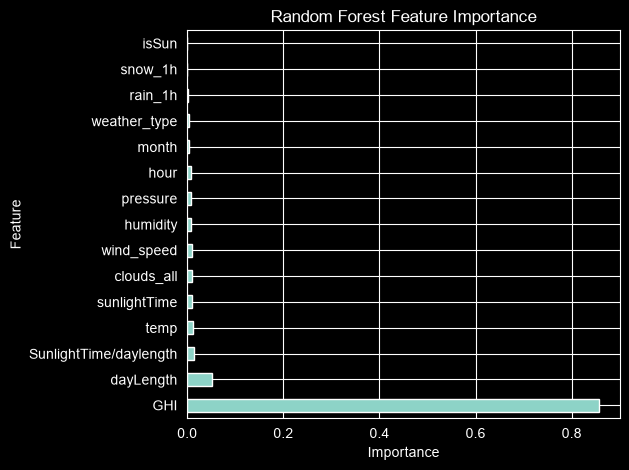

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

feature_importance.plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/08_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

The feature importance visualization shows that GHI overwhelmingly dominates all other variables in the Random Forest model. Day length contributes a smaller but noticeable amount of predictive information, while most remaining features have relatively minor importance.

**Interpretation:**

The model relies primarily on solar irradiance to predict renewable energy production. Additional weather and temporal variables contribute supplementary information, but their influence is substantially smaller once GHI is available.

**Key Finding:**

Feature importance analysis confirms that solar irradiance is the dominant factor influencing renewable energy generation and is responsible for the majority of the model's predictive power.

### XGBoost Regression Model

### Training the XGBoost Model

In [42]:
import xgboost
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### Evaluating the XGBoost Model

In [43]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Results")
print("MAE :", round(xgb_mae, 2))
print("RMSE:", round(xgb_rmse, 2))
print("R²  :", round(xgb_r2, 4))

XGBoost Results
MAE : 115.89
RMSE: 276.78
R²  : 0.9305


**Observation:**

The XGBoost model achieved an R² score of 0.9305, an MAE of 115.89 Wh, and an RMSE of 276.78 Wh.

**Interpretation:**

Although XGBoost produced strong predictive performance, it did not outperform the Random Forest model. This suggests that the Random Forest algorithm is particularly well-suited to the structure of this renewable energy dataset.

**Key Finding:**

Among the three evaluated models, Random Forest achieved the best overall performance with an R² score of 0.9365.

In [44]:
comparison = {
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        224.02,
        106.02,
        115.89
    ],
    "RMSE": [
        396.71,
        264.56,
        276.78
    ],
    "R2": [
        0.8572,
        0.9365,
        0.9305
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,MAE,RMSE,R2
0,Linear Regression,224.02,396.71,0.8572
1,Random Forest,106.02,264.56,0.9365
2,XGBoost,115.89,276.78,0.9305
